# TQD2026 notebook 3: *Lindblad Master equation evolution*
## Vectorized MPS approach to Markovian Open Quantum Systems

This notebook switches from purified wavefunctions to direct vectorization of density matrices. Each MPS "site" now represents a local operator, so for a spin-half chain each local MPS index has dimension `2^2 = 4`. We use the column-vectorization convention for a `d` dimensional local system:

```text
rho[a,b] |a><b|  ->  vec(rho)[a + (b-1)d]
```

so

```text
A rho B  ->  (B^T ⊗ A) vec(rho).
```

The Lindbladian `L` is compiled into an `OpSum` on the vectorized sites, then the existing Trotter MPO construction tools used in previous notebooks is used again to build a one-step propagator for `exp(L dt)`.

In [1]:
using ITensors
using ITensorMPS
using LinearAlgebra
using Plots
using Printf

include("MPS_MPO_helpers.jl")
using .MPS_MPO_helpers

# Local scope copy of the operators for convenience:
const I2 = ComplexF64[1 0; 0 1]
const Sp = ComplexF64[0 1; 0 0]
const Sm = ComplexF64[0 0; 1 0]
const Sz = ComplexF64[0.5 0; 0 -0.5]
const Sx = 0.5 * ComplexF64[0 1; 1 0]
const Sy = 0.5 * ComplexF64[0 -im; im 0]

default(; linewidth=2, grid=false, framestyle=:box)

## Example 1: Heisenberg Chain With Local Amplitude Damping

The Hamiltonian and each jump operator are written explicitly as `OpSum`s. The important convention is that `jumps` is a vector of `OpSum`s: each entry is one Lindblad operator `J_mu`. Putting multiple jumps into a single `OpSum` would instead define one collective jump and would generate cross terms.

In [2]:
N_loss = 4
dt_loss = 0.05
nsteps_loss = 80
sites_loss = siteinds("Qudit", N_loss; dim=4)

H_loss = OpSum()
for j in 1:(N_loss - 1)
  H_loss += "Sz", j, "Sz", j + 1
  H_loss += 0.5, "S+", j, "S-", j + 1
  H_loss += 0.5, "S-", j, "S+", j + 1
end

jumps_loss = OpSum[]
gamma = 0.4
for j in 1:N_loss
  J = OpSum()
  J += sqrt(gamma), "S-", j
  push!(jumps_loss, J)
end;

Construct the Lindbladian `OpSum`, use this to generate the Trotter circuit and its corresponding one-time-step MPO propagator. Also create an initial an Neel initial state.

In [5]:
L_loss = lindbladian_opsum(H_loss, jumps_loss)
layers_loss = second_order_trotter_circuit(L_loss, sites_loss, dt_loss; evolution_factor=1, max_range=2)
Udt_loss = circuit_mpo(layers_loss, sites_loss; cutoff=0)

rho_loss0 = product_operator_mps(
  sites_loss,
  [isodd(j) ? (I2-2Sz) : (I2+2Sz) for j in 1:N_loss],
)
tr_loss = trace_mps(sites_loss)
normalize_trace!(rho_loss0, tr_loss);

In [14]:
loss_times = Float64[]
loss_trace_err = Float64[]
loss_sz_mid = Float64[]
loss_maxdim = Int[]

cutoff_evolve = 1e-16

sz_mid_loss = div(N_loss, 2)

rho_loss = copy(rho_loss0)

for step in 0:nsteps_loss
  push!(loss_times, step * dt_loss)
  push!(loss_trace_err, abs(1-real(trace_value(rho_loss, tr_loss))))
  push!(loss_sz_mid, expect_liouville(rho_loss, tr_loss, sites_loss, [(sz_mid_loss, Sz)]))
  push!(loss_maxdim, maxlinkdim(rho_loss))

  step == nsteps_loss && break
  rho_loss = apply_mpo_step(Udt_loss, rho_loss; cutoff=cutoff_evolve, maxdim=16, normalize=false)
  #normalize_trace!(rho_loss, tr_loss) # We don't force the trace normalization.
end

println(@sprintf("final trace error = %.12f", loss_trace_err[end]))
println(@sprintf("final middle-site <Sz> = %.12f", loss_sz_mid[end]))
println("max link dimension reached = ", maximum(loss_maxdim))

final trace error = 0.000000006836
final middle-site <Sz> = -0.357584570819
max link dimension reached = 16


Now perform the same calculation but using exact diagonalization instead (possible only for small systems):

In [7]:
L_loss_matrix = dense_operator_matrix(L_loss, sites_loss)
Udt_loss_exact = exp(dt_loss * L_loss_matrix)

tr_loss_vec = dense_state_vector(tr_loss, sites_loss)
sz_mid_loss_vec = dense_state_vector(observable_mps(sites_loss, [(sz_mid_loss, Sz)]), sites_loss)
rho_loss_exact = dense_state_vector(rho_loss0, sites_loss)

loss_trace_err_exact = Float64[]
loss_sz_mid_exact = Float64[]

for step in 0:nsteps_loss
  exact_trace = dot(tr_loss_vec, rho_loss_exact)

  push!(loss_trace_err_exact, abs(1-real(exact_trace)))
  push!(loss_sz_mid_exact, real(dot(sz_mid_loss_vec, rho_loss_exact) / exact_trace))

  step == nsteps_loss && break
  rho_loss_exact = Udt_loss_exact * rho_loss_exact
end

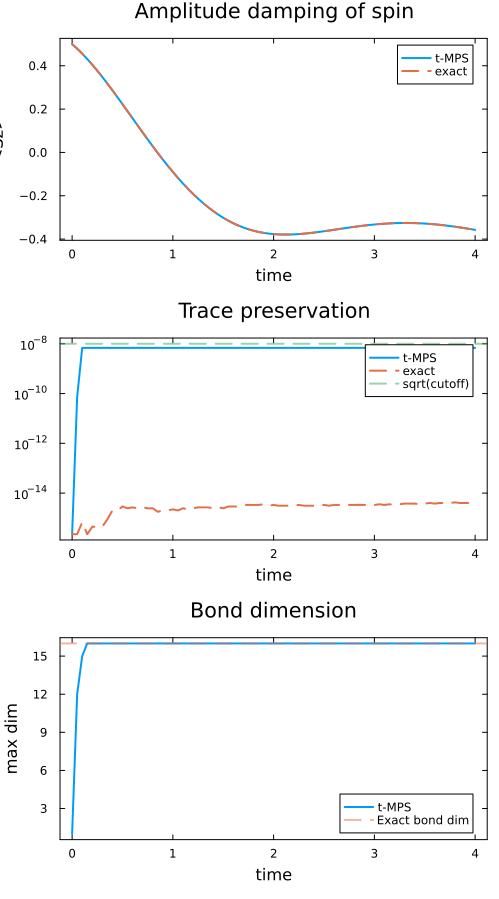

In [17]:
p1 = plot(
  loss_times,
  loss_sz_mid;
  xlabel="time",
  ylabel="<Sz>",
  label="t-MPS",
  title="Amplitude damping of spin",
)
plot!(p1, loss_times, loss_sz_mid_exact; linestyle=:dash, label="exact")

p2 = plot(
  loss_times,
  loss_trace_err.+ eps(Float64);
  xlabel="time",
  ylabel="1- Tr rho",
  label="t-MPS",
  title="Trace preservation",
  yscale=:log10,
)
plot!(p2, loss_times, loss_trace_err_exact .+ eps(Float64); linestyle=:dash, label="exact")
hline!(p2, [sqrt(cutoff_evolve)]; linestyle=:dash, alpha=0.5, label="sqrt(cutoff)")

p3 = plot(
  loss_times,
  loss_maxdim;
  xlabel="time",
  ylabel="max dim",
  label="t-MPS",
  title="Bond dimension",
)
hline!(p3, [4^(N_loss/2)]; linestyle=:dash, alpha=0.5, label="Exact bond dim")

plot(p1, p2, p3; layout=(3, 1), size=(500, 900))

Notice that `maxdim=16` means “keep up to 16 states, subject to discarding weight below the cutoff”, so we still see some cut-off induced truncation during the evolution even though we are technically allowing the full exact bond dimension. This is the cause of the drift of the trace from unity. To remove it we set `cutoff=0`. The trace will still drift from unity due to arithmetic rounding errors, but will be orders of magnitude smaller.

## Example 2: Boundary-Driven XXZ Chain

Now use boundary injection/removal jumps. The Hamiltonian is the XXZ model

$$
    H = \sum_j \frac{1}{2}J_{xy} (S^+_j S^-_{j+1} + S^-_j S^+_{j+1}) + \Delta S^z_j S^z_{j+1}.
$$

The boundary driving is parameterized by an overall rate `Gamma` and a bias `f = [-1,1]` giving in/out rates as `Gamma(1±f)/2`.

<center>
<img src="images/boundary_driven.png" width="400">
</center>


Here we set `Delta = 0`, giving the (analytically solvable) noninteracting XX limit from which we can compare against an exact result encoded in this function:

In [7]:
function xx_boundary_steady_state(fL, fR, Gamma, Jxy)
  denom = Gamma^2 + Jxy^2
  bias_difference = fL - fR
  boundary_shift = Jxy^2 * bias_difference / (4 * denom)
  current = Gamma * Jxy * bias_difference / (4 * denom)
  return (;
    sz_left=fL / 2 - boundary_shift,
    sz_right=fR / 2 + boundary_shift,
    sz_bulk=(fL + fR) / 4,
    current,
  )
end;

Define the system:

In [8]:
N_driven = 8
sites_driven = siteinds("Qudit", N_driven; dim=4)

dt_driven = 0.05
nsteps_driven = 750
Jxy = 1.0
Delta = 0.0
Gamma = 1.0
fL = 1
fR = -1

N_driven < 2 && error("Boundary driving needs at least two sites.")
Gamma > 0 || error("The analytic boundary-driven comparison assumes Gamma > 0.")
(-1 <= fL <= 1 && -1 <= fR <= 1) || error("Reservoir biases fL and fR must lie between -1 and 1.")
left_site = 1
right_site = N_driven
centre_site = Int(floor(N_driven/2));

Construct the XXZ Hamiltonian and boundary jump operators, and then package them up into the Lindbladian for splitting into a Trotter circuit and superoperator time-step MPO. Also construct a completely mixed initial density operator:

In [9]:
H_driven = OpSum()
for j in 1:(N_driven - 1)
  H_driven += 0.5Jxy, "S+", j, "S-", j + 1
  H_driven += 0.5Jxy, "S-", j, "S+", j + 1
  H_driven += Delta, "Sz", j, "Sz", j + 1
end

jumps_driven = OpSum[]
J = OpSum(); J += sqrt(Gamma * (1 + fL)/2), "S+", left_site; push!(jumps_driven, J)
J = OpSum(); J += sqrt(Gamma * (1 - fL)/2), "S-", left_site; push!(jumps_driven, J)
J = OpSum(); J += sqrt(Gamma * (1 + fR)/2), "S+", right_site; push!(jumps_driven, J)
J = OpSum(); J += sqrt(Gamma * (1 - fR)/2), "S-", right_site; push!(jumps_driven, J)

L_driven = lindbladian_opsum(H_driven, jumps_driven)
layers_driven = second_order_trotter_circuit(L_driven, sites_driven, dt_driven; evolution_factor=1, max_range=2)
Udt_driven = circuit_mpo(layers_driven, sites_driven; cutoff=1e-13)

rho_driven = product_operator_mps(sites_driven, [I2 / 2 for _ in 1:N_driven])
tr_driven = trace_mps(sites_driven)
normalize_trace!(rho_driven, tr_driven);

Now compute the real time-evolution for sufficiently long that the system relaxes to the steady-state:

In [10]:
trace_driven = Float64[]
sz_left_driven = Float64[]
sz_bulk_driven = Float64[]
sz_right_driven = Float64[]
current_driven = Float64[]
times_driven = Float64[]

for step in 0:nsteps_driven
  push!(times_driven, step * dt_driven)
  push!(trace_driven, real(trace_value(rho_driven, tr_driven)))
  push!(sz_left_driven, expect_liouville(rho_driven, tr_driven, sites_driven, [(left_site, Sz)]))
  push!(sz_bulk_driven, expect_liouville(rho_driven, tr_driven, sites_driven, [(centre_site, Sz)]))
  push!(sz_right_driven, expect_liouville(rho_driven, tr_driven, sites_driven, [(right_site, Sz)]))

  current = real(
    0.5im * expect_liouville_complex(rho_driven, tr_driven, sites_driven, [(centre_site, Sp), (centre_site + 1, Sm)]) -
    0.5im * expect_liouville_complex(rho_driven, tr_driven, sites_driven, [(centre_site, Sm), (centre_site + 1, Sp)])
  )
  push!(current_driven, current)

  step == nsteps_driven && break
  rho_driven = apply_mpo_step(Udt_driven, rho_driven; cutoff=1e-12, maxdim=100, normalize=false)
end

println(@sprintf("steady <Sz_left> = %.5f", sz_left_driven[end]))
println(@sprintf("steady <Sz_bulk> = %.5f", sz_bulk_driven[end]))
println(@sprintf("steady <Sz_right> = %.5f", sz_right_driven[end]))
println(@sprintf("steady current on bond (%d-%d) = %.5f", centre_site, centre_site + 1, current_driven[end]))
println(@sprintf("final trace error = %.12f", 1-trace_driven[end]))

steady <Sz_left> = 0.25078
steady <Sz_bulk> = 0.00068
steady <Sz_right> = -0.25077
steady current on bond (4-5) = 0.24928
final trace error = 0.000040380952


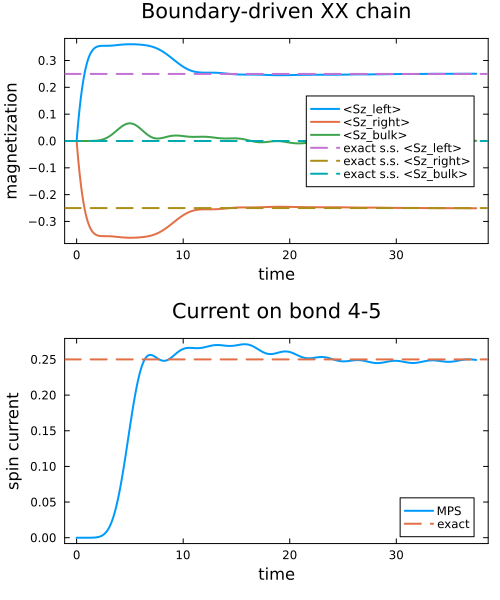

In [11]:
analytic_driven = xx_boundary_steady_state(fL, fR, Gamma, Jxy)

p_mag = plot(
  times_driven,
  sz_left_driven;
  xlabel="time",
  ylabel="magnetization",
  label="<Sz_left>",
  title="Boundary-driven XX chain",
  legend=:right,
)
plot!(p_mag, times_driven, sz_right_driven; label="<Sz_right>")
plot!(p_mag, times_driven, sz_bulk_driven; label="<Sz_bulk>")
hline!(p_mag, [[analytic_driven.sz_left]]; linestyle=:dash, label="exact s.s. <Sz_left>")
hline!(p_mag, [[analytic_driven.sz_right]]; linestyle=:dash, label="exact s.s. <Sz_right>")
hline!(p_mag, [[analytic_driven.sz_bulk]]; linestyle=:dash, label="exact s.s. <Sz_bulk>")


p_current = plot(
  times_driven,
  current_driven;
  xlabel="time",
  ylabel="spin current",
  label="MPS",
  title="Current on bond $(centre_site)-$(centre_site + 1)",
)
hline!(p_current, [[analytic_driven.current]]; linestyle=:dash, label="exact")

plot(p_mag, p_current; layout=(2, 1), size=(500, 600))

We see excellent agreement with the analytic exact result. However, the MPS calculation can also easily run for non-zero `Delta`. Give it a try!